In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=1.04430667/cloudy_fits/'

Species names

In [5]:
ion_list = ['HI', 'HeI', 'CII', 'CIII', 'CIV', 'NII', 'NIII', 'NIV', 'NV',
            'OII', 'OIII', 'OIV', 'OV', 'OVI', 'SiII', 'SiIII', 'SiIV',
            'MgII', 'MgX', 'NeV', 'NeVI', 'NeVIII', 'SIV', 'SV', 'SVI']

Specify density/metallicity grid

In [6]:
log_metals_arr = [-2.6,-2.4,-2.2,-2.0,-1.8,-1.6,-1.4,-1.2,-1.0 ,-0.8,-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6,0.8,1.0]
log_hdens_arr = [-4.8,-4.4,-4.2,-4.0,-3.8,-3.6,-3.4,-3.2,-3.0,-2.8,-2.6,-2.4,-2.2,-2.0,-1.8,-1.6]
logT_arr = np.arange(4.00, 6.01, 0.01)

Load grids

In [7]:
pkl_file = open(rootdir+'TDP_grid.pkl', 'rb')
logX_dict_TDP_samples = pickle.load(pkl_file)
pkl_file.close()

Set up the 3D grid across metallicity, density, and temperature

In [8]:
logX_dict_TDP_interp = {}

for ion in ion_list:
    logX_dict_TDP_interp[ion] = RegularGridInterpolator((log_metals_arr, log_hdens_arr, logT_arr), 
                                                     logX_dict_TDP_samples[ion])

# c1

## Make diagnostics

In [21]:
logN_dict = {'HI':'14.8, -0.1, +0.2',
        'HeI':'<13.1',
        #'CII':'<13.0',
        'CIII':'13.9, -0.4, +0.5',
        'CIV':'13.62, -0.03, +0.03',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.3',
        'OIII':'14.33, -0.07, +0.07',
        'OIV':'14.47, -0.07, +0.07',
        'OV':'14.01, -0.05, +0.08',
        'OVI':'13.8, -0.2, +0.1',}
        #'NeV':'<13.7',
        #'MgII':'<11.3',
        #'MgX':'<13.6',
        #'AlII':'<11.1',
        #'AlIII':'<11.5',
        #'SiII':'<12.1',
        #'SIV':'<13.9',
        #'SVI':'<13.3',
        #'FeII':'<11.6',}

## CIII, CIV, OIV

In [22]:
gen_logN_ratio_str(logN_dict['CIV'], logN_dict['CIII'])

'-0.28, -0.40, 0.50'

In [23]:
logN_ratio_dict = {'CIV/CIII': '-0.28, -0.40, 0.50',
                   'OIV/OIII': '0.14, -0.10, 0.10',
                  }

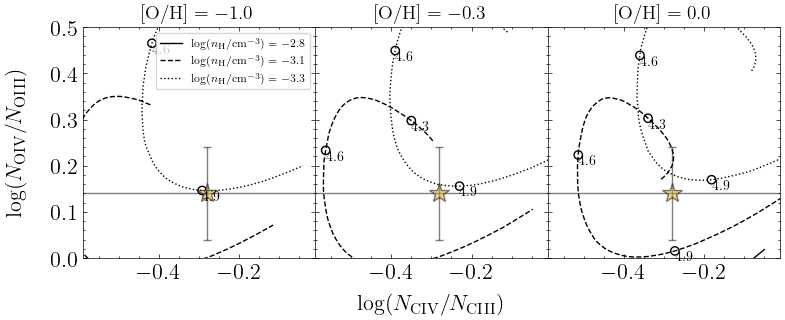

In [24]:
fig, axes = plt.subplots(1,3,figsize=(3*3,3), sharex=True, sharey=True)

# Plot measurements

scat_logN_ratio(axes[0], 'CIV/CIII', 'OIV/OIII', logN_ratio_dict)
axes[0].set_title(r'$\mathrm{[O/H]}=-1.0$', fontsize=14)

scat_logN_ratio(axes[1], 'CIV/CIII', 'OIV/OIII', logN_ratio_dict)
axes[1].set_title(r'$\mathrm{[O/H]}=-0.3$', fontsize=14)

scat_logN_ratio(axes[2], 'CIV/CIII', 'OIV/OIII', logN_ratio_dict)
axes[2].set_title(r'$\mathrm{[O/H]}=0.0$', fontsize=14)

ax_label = fig.add_subplot(111, frameon=False)
ax_label.set_xticks([])
ax_label.set_yticks([])

ax_label.set_xlabel(r'$\log(N_\mathrm{CIV}/N_\mathrm{CIII})$', labelpad=25)
ax_label.set_ylabel(r'$\log(N_\mathrm{OIV}/N_\mathrm{OIII})$', labelpad=40)

plt.subplots_adjust(wspace=0, hspace=0.0)

# Plot tracks
# metals = -1.0

plot_logN_ratio_track(axes[0], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      -1.0, -2.8, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[0], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      -1.0, -3.1, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[0], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      -1.0, -3.3, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      ':', 'left', 'top')

axes[0].legend(fontsize=8)

# metals = -0.3

plot_logN_ratio_track(axes[1], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      -0.3, -2.8, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[1], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      -0.3, -3.1, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[1], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      -0.3, -3.3, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      ':', 'left', 'top')

# metals = 0.0

plot_logN_ratio_track(axes[2], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.0, -2.8, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[2], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.0, -3.1, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[2], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.0, -3.3, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      ':', 'left', 'top')

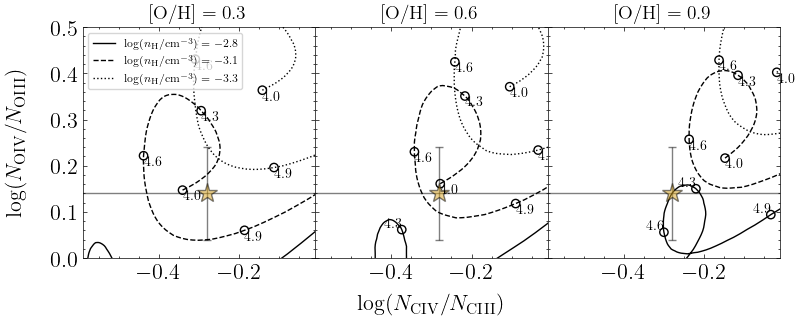

In [25]:
fig, axes = plt.subplots(1,3,figsize=(3*3,3), sharex=True, sharey=True)

# Plot measurements

scat_logN_ratio(axes[0], 'CIV/CIII', 'OIV/OIII', logN_ratio_dict)
axes[0].set_title(r'$\mathrm{[O/H]}=0.3$', fontsize=14)

scat_logN_ratio(axes[1], 'CIV/CIII', 'OIV/OIII', logN_ratio_dict)
axes[1].set_title(r'$\mathrm{[O/H]}=0.6$', fontsize=14)

scat_logN_ratio(axes[2], 'CIV/CIII', 'OIV/OIII', logN_ratio_dict)
axes[2].set_title(r'$\mathrm{[O/H]}=0.9$', fontsize=14)

ax_label = fig.add_subplot(111, frameon=False)
ax_label.set_xticks([])
ax_label.set_yticks([])

ax_label.set_xlabel(r'$\log(N_\mathrm{CIV}/N_\mathrm{CIII})$', labelpad=25)
ax_label.set_ylabel(r'$\log(N_\mathrm{OIV}/N_\mathrm{OIII})$', labelpad=40)

plt.subplots_adjust(wspace=0, hspace=0.0)

# Plot tracks
# metals = -1.0

plot_logN_ratio_track(axes[0], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.3, -2.8, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[0], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.3, -3.1, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[0], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.3, -3.3, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      ':', 'left', 'top')

axes[0].legend(fontsize=8)

# metals = -0.3

plot_logN_ratio_track(axes[1], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.6, -2.8, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[1], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.6, -3.1, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[1], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.6, -3.3, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      ':', 'left', 'top')

# metals = 0.0

plot_logN_ratio_track(axes[2], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.9, -2.8, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[2], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.9, -3.1, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[2], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.9, -3.3, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      ':', 'left', 'top')

## HI

Text(0, 0.5, '$\\log(N_\\mathrm{HI}/\\mathrm{cm}^{-2})$')

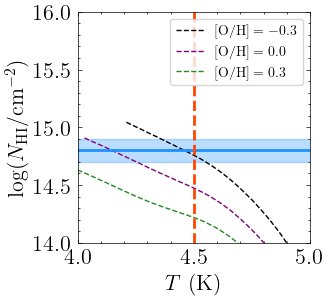

In [26]:
fig, ax = plt.subplots(1, figsize=(3,3))

logT_filt, logN_HI_filt = get_logN_HI('OIV', 14.47, -0.3, -3.0, logT_arr, logX_dict_TDP_interp)
ax.plot(logT_filt, logN_HI_filt,color='black', linestyle='--', label=r'$\mathrm{[O/H]}=-0.3$')

logT_filt, logN_HI_filt = get_logN_HI('OIV', 14.47, 0.0, -3.0, logT_arr, logX_dict_TDP_interp)
ax.plot(logT_filt, logN_HI_filt,color='purple', linestyle='--', label=r'$\mathrm{[O/H]}=0.0$')

logT_filt, logN_HI_filt = get_logN_HI('OIV', 14.47, 0.3, -3.0, logT_arr, logX_dict_TDP_interp)
ax.plot(logT_filt, logN_HI_filt,color='forestgreen', linestyle='--', label=r'$\mathrm{[O/H]}=0.3$')

ax.axhline(14.8, color='dodgerblue', lw=2)
ax.axhspan(14.7,14.9, color='dodgerblue',alpha=.3)
ax.axvline(4.5, color='orangered', lw=2, linestyle='--')

ax.set_xlim(4.0, 5.0)
ax.set_ylim(14, 16)

ax.legend(fontsize=10, loc='upper right')
ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\log(N_\mathrm{HI}/\mathrm{cm}^{-2})$')

## Fit column densities

In [75]:
def log_prior(log_metals, log_hdens, logT, C_O, N_O):
    
    if log_metals_arr[0]<log_metals<log_metals_arr[-1] and -3<log_metals+C_O<1 and -3<log_metals+N_O<1: #[C/H]
        if log_hdens_arr[0]<log_hdens<log_hdens_arr[-1]:
            if 4.1<logT<4.4: # Temperature limit based on CIV linewidth
                return np.log(10**log_hdens) + np.log(10**logT)
            else:
                return -np.inf
        else:
            return -np.inf
    else:
        return -np.inf

In [76]:
def log_likelihood(log_metals, log_hdens, logT, C_O, N_O, logN_dict, logX_dict_TDP_interp):
    
    logN_HI_obs = 14.8 # Measured N(HI) to generate column densities
    
    ll = 0
    
    for ion in list(logN_dict.keys()):
        
        # Model side: prediction adjusted for elemental abundance
        elem = ion_species_dict[ion].split('+')[0]
        
        y_bar = predict_col_dens_TDP(ion, log_metals, log_hdens, logT, logN_HI_obs, logX_dict_TDP_interp)
        if elem == 'C':
            y_bar += C_O 
        if elem == 'N':
            y_bar += N_O
            
        # Data side: handle upper limits, lower limits, and measurements separately
        logN_str = logN_dict[ion]
        
        ll += compute_ll(logN_str, y_bar)

    return ll

In [77]:
def log_probability(params, logN_dict, logX_dict_TDP_interp):
    
    log_metals, log_hdens, logT, C_O, N_O = params
    
    lp = log_prior(log_metals,log_hdens,logT,C_O,N_O)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp+log_likelihood(log_metals,log_hdens,logT,C_O,N_O,logN_dict,logX_dict_TDP_interp)

In [78]:
logN_dict = {#'HI':'14.8, -0.1, +0.1',
        'HeI':'<13.1',
        'CII':'<13.0',
        'CIII':'13.9, -0.4, +0.5',
        'CIV':'13.62, -0.03, +0.03',
        'NIV':'13.0, -0.1, +0.1',
        'NV':'<13.3',
        'OIII':'14.33, -0.07, +0.07',
        'OIV':'14.47, -0.07, +0.07',
        'OV':'<14.01',
        'OVI':'<13.8',
        'NeV':'<13.7',
        'MgII':'<11.3',
        #'MgX':'<13.6',
        #'AlII':'<11.1',
        #'AlIII':'<11.5',
        'SiII':'<12.1',
        'SIV':'<13.9',
        'SVI':'<13.3',}
        #'FeII':'<11.6',}

In [79]:
log_metals_test = -0.2
log_hdens_test = -3.0
logT_test = 4.3
logN_HI_test = 14.8
C_O_test = -0.2
N_O_test = -0.6

logN_test = predict_col_dens_model_TDP(logN_dict,log_metals_test,log_hdens_test,logT_test,logN_HI_test,logX_dict_TDP_interp, C_O_test, N_O_test)

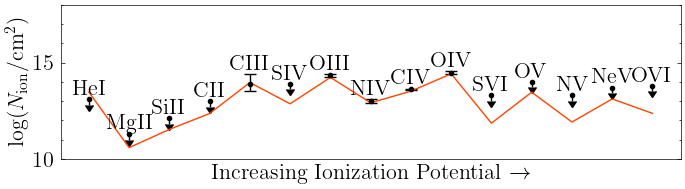

In [80]:
fig, ax = plt.subplots(1, figsize=(8,2))

plot_column_densities_obs(logN_dict, fig, ax)

ax.plot(np.arange(len(logN_dict)), logN_test, color='orangered')
#ax.set_ylim(12.5,14)

In [81]:
logN_test[0]

13.46142407045515

In [82]:
pos = np.array([log_metals_test, log_hdens_test, logT_test, C_O_test, N_O_test]) + 1e-4 * np.random.randn(200, 5)
nwalkers, ndim = pos.shape

In [83]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, logX_dict_TDP_interp)
)

In [88]:
#sampler.run_mcmc(pos, 500, progress=True);

In [89]:
#flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_metals', 'log_hdens', 'logT', 'C_O', 'N_O'])
#flat_samples.to_csv(savedir+'TDP_c1.csv', index=False)

flat_samples = pd.read_csv(savedir+'TDP_c1.csv')

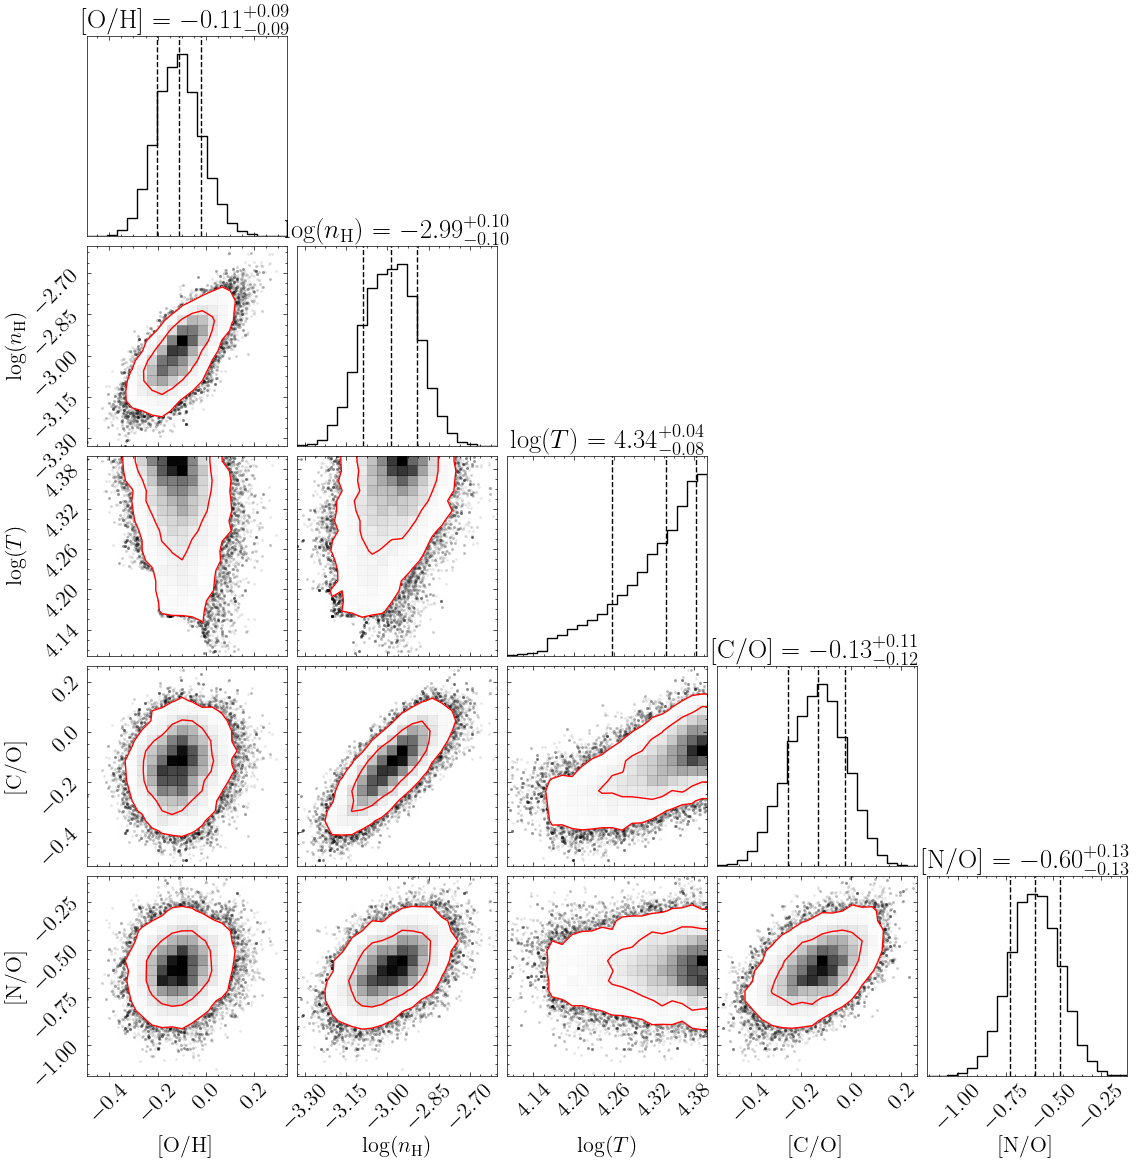

In [90]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\mathrm{[O/H]}$', r'$\log(n_\mathrm{H})$', r'$\log(T)$', r'$\mathrm{[C/O]}$',r'$\mathrm{[N/O]}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [91]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.399779741300468

(array([   85.,   784.,  4376., 13637., 22678., 21177., 12150.,  4258.,
          757.,    98.]),
 array([-1.3521319 , -1.22192616, -1.09172042, -0.96151467, -0.83130893,
        -0.70110318, -0.57089744, -0.44069169, -0.31048595, -0.1802802 ,
        -0.05007446]),
 <BarContainer object of 10 artists>)

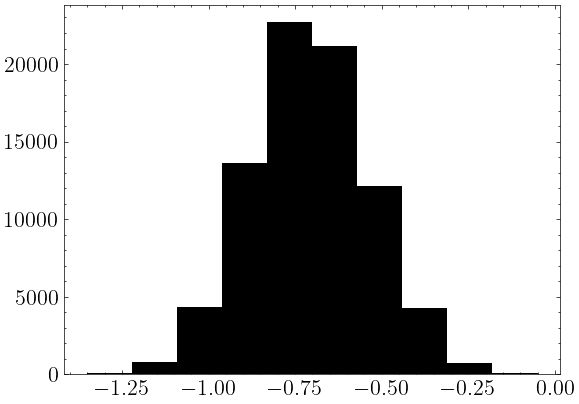

In [92]:
plt.hist(flat_samples['log_metals']+flat_samples['N_O'])

In [93]:
np.percentile(flat_samples['N_O'], 100*cdf_3sig)

-0.20602831060511323

Make a plot

In [94]:
logN_dict = {#'HI':'14.8, -0.1, +0.2',
        'HeI':'<13.1',
        'CII':'<13.0',
        'CIII':'13.9, -0.4, +0.5',
        'CIV':'13.62, -0.03, +0.03',
        'NIV':'13.0, -0.1, +0.1',
        'NV':'<13.3',
        'OIII':'14.33, -0.07, +0.07',
        'OIV':'14.47, -0.07, +0.07',
        'OV':'14.01, -0.05, +0.08',
        'OVI':'13.8, -0.2, +0.1',
        'NeV':'<13.7',
        'MgII':'<11.3',
        #'MgX':'<13.6',
        #'AlII':'<11.1',
        #'AlIII':'<11.5',
        'SiII':'<12.1',
        'SIV':'<13.9',
        'SVI':'<13.3',}
        #'FeII':'<11.6',}

In [95]:
b_dict = {'HI':'19, -1, +1',
          'CIII':'6.8, -0.2, +0.2',
          'CIV':'6.8, -0.2, +0.2',
          'NIV':'6.8, -0.2, +0.2',
          'OIII':'6.8, -0.2, +0.2',
          'OIV':'6.8, -0.2, +0.2',
          'OV':'18, -3, +2',
          'OVI':'18, -3, +2'}

In [96]:
p_grid = np.array(flat_samples)

yb_med = np.zeros(len(logN_dict))
yb_lo = np.zeros(len(logN_dict))
yb_hi = np.zeros(len(logN_dict))

ctr = 0

for i in range(len(ion_species_dict)):
    
    ion = list(ion_species_dict.keys())[i]
    elem = ion_species_dict[ion].split('+')[0]
    
    if ion in list(logN_dict.keys()):
        
        y_samples = predict_col_dens_TDP(ion, p_grid[:,0], p_grid[:,1], p_grid[:,2], 14.8, logX_dict_TDP_interp)
        if elem == 'C':
            y_samples += p_grid[:,3]
        if elem == 'N':
            y_samples += p_grid[:,4]

        yb_med[ctr] = np.median(y_samples)
        yb_lo[ctr] = np.percentile(y_samples, 16)
        yb_hi[ctr] = np.percentile(y_samples, 84)
        
        ctr += 1

In [97]:
import matplotlib.lines as mlines

In [98]:
z_sys = 1.04430667

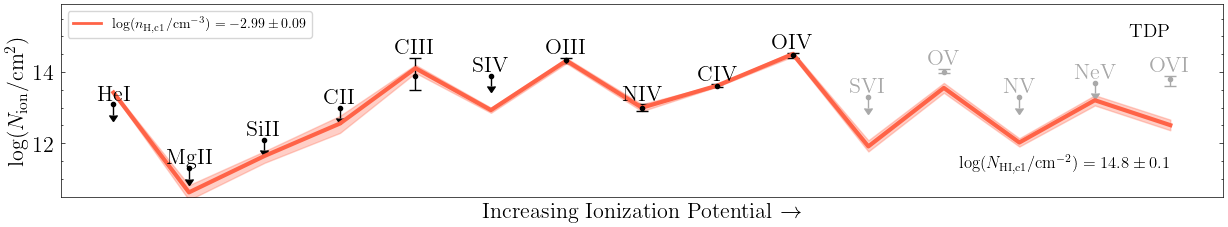

In [99]:
fig, ax = plt.subplots(1, figsize=(15,2.5))

plot_column_densities_obs(logN_dict, fig, ax,
                   gray_out = ['NV', 'OV', 'OVI', 'NeV','SVI'])

ax.plot(np.arange(len(logN_dict)), yb_med, lw=3, color='tomato')
ax.fill_between(np.arange(len(logN_dict)), yb_lo, yb_hi, color='tomato', alpha=.3)

ax.set_ylim(10.5,15.9)

ax.text(len(logN_dict)-1, 15.0, r'TDP', fontsize=14,horizontalalignment='right')

ax.text(len(logN_dict)-1, 11.3, r'$\log(N_\mathrm{HI, c1}/\mathrm{cm}^{-2}) = 14.8 \pm 0.1$', fontsize=12,
            horizontalalignment='right')

handles = []

handles.append(mlines.Line2D([], [], lw=2,
                             color='tomato', 
                             marker='None',
              linestyle='-', markersize=8, label=r'$\log(n_\mathrm{H,c1}/\mathrm{cm}^{-3}) = -2.99 \pm 0.09$'))

ax.legend(handles=handles, loc='upper left', fontsize=10)

plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z={}/z={}_c1_TDP.pdf'.format(z_sys, str(z_sys).replace('.', '_')), dpi=150)
plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z={}/z={}_c1_TDP.png'.format(z_sys, str(z_sys).replace('.', '_')), dpi=150)

In [100]:
yb_med[0]

13.42269403395535

Cloud size posterior

In [101]:
logl = get_logl_TDP(p_grid[:,0], p_grid[:,1], p_grid[:,2], 14.8, logX_dict_TDP_interp)

(array([3.9530e+03, 6.2182e+04, 1.3465e+04, 1.3900e+02, 1.1300e+02,
        5.4000e+01, 3.2000e+01, 1.5000e+01, 3.4000e+01, 1.3000e+01]),
 array([-1.08705797, -0.61476068, -0.14246339,  0.3298339 ,  0.80213119,
         1.27442848,  1.74672577,  2.21902306,  2.69132035,  3.16361763,
         3.63591492]),
 <BarContainer object of 10 artists>)

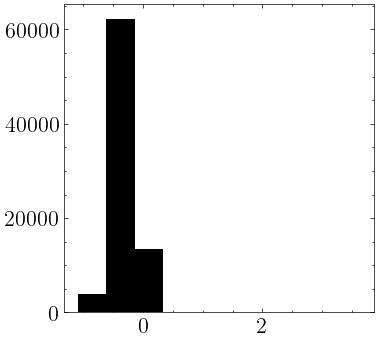

In [102]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logl)

In [103]:
get_quantiles(logl)

-0.32 -0.18 0.18


# c4

## Make diagnostics

In [127]:
logN_dict = {#'HI':'14.5, -0.1, +0.1',
            #'HeI':'<13.1',
            #'CII':'<13.0',
            'CIII':'13.1, -0.4, +0.3',
            'CIV':'13.52, -0.03, +0.03',
            #'NIV':'13.0, -0.1, +0.1',
            #'NV':'<13.3',
            'OIII':'13.6, -0.1, +0.1',
            'OIV':'13.9, -0.2, +0.1',}
            #'OV':'13.6, -0.2, +0.1',
            #'OVI':'<13.8',
            #'NeV':'<13.7',
            #'MgII':'<11.3',
            #'MgX':'<13.6',
            #'AlII':'<11.1',
            #'AlIII':'<11.5',
            #'SiII':'<12.1',
            #'SIV':'<13.9',
            #'SVI':'<13.3',
            #'FeII':'<11.6',}

## CIII, CIV, OIV

In [128]:
gen_logN_ratio_str(logN_dict['OIV'], logN_dict['OIII'])

'0.30, -0.22, 0.14'

In [129]:
logN_ratio_dict = {'CIV/CIII': '0.42, -0.40, 0.30',
                   'OIV/OIII': '0.30, -0.22, 0.14',
                  }

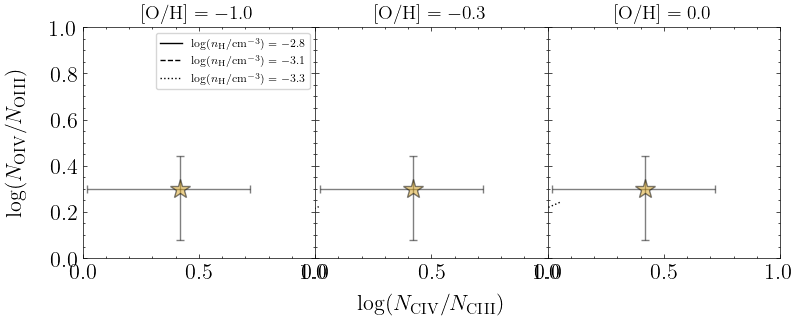

In [130]:
fig, axes = plt.subplots(1,3,figsize=(3*3,3), sharex=True, sharey=True)

# Plot measurements

scat_logN_ratio(axes[0], 'CIV/CIII', 'OIV/OIII', logN_ratio_dict)
axes[0].set_title(r'$\mathrm{[O/H]}=-1.0$', fontsize=14)

scat_logN_ratio(axes[1], 'CIV/CIII', 'OIV/OIII', logN_ratio_dict)
axes[1].set_title(r'$\mathrm{[O/H]}=-0.3$', fontsize=14)

scat_logN_ratio(axes[2], 'CIV/CIII', 'OIV/OIII', logN_ratio_dict)
axes[2].set_title(r'$\mathrm{[O/H]}=0.0$', fontsize=14)

ax_label = fig.add_subplot(111, frameon=False)
ax_label.set_xticks([])
ax_label.set_yticks([])

ax_label.set_xlabel(r'$\log(N_\mathrm{CIV}/N_\mathrm{CIII})$', labelpad=25)
ax_label.set_ylabel(r'$\log(N_\mathrm{OIV}/N_\mathrm{OIII})$', labelpad=40)

plt.subplots_adjust(wspace=0, hspace=0.0)

# Plot tracks
# metals = -1.0

plot_logN_ratio_track(axes[0], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      -1.0, -2.8, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      0.0,1.0, 0.0,1.0,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[0], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      -1.0, -3.1, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      0.0,1.0, 0.0,1.0,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[0], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      -1.0, -3.3, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      0.0,1.0, 0.0,1.0,
                      ':', 'left', 'top')

axes[0].legend(fontsize=8)

# metals = -0.3

plot_logN_ratio_track(axes[1], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      -0.3, -2.8, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      0.0,1.0, 0.0,1.0,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[1], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      -0.3, -3.1, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      0.0,1.0, 0.0,1.0,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[1], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      -0.3, -3.3, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      0.0,1.0, 0.0,1.0,
                      ':', 'left', 'top')

# metals = 0.0

plot_logN_ratio_track(axes[2], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.0, -2.8, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      0.0,1.0, 0.0,1.0,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[2], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.0, -3.1, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      0.0,1.0, 0.0,1.0,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[2], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.0, -3.3, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      0.0,1.0, 0.0,1.0,
                      ':', 'left', 'top')

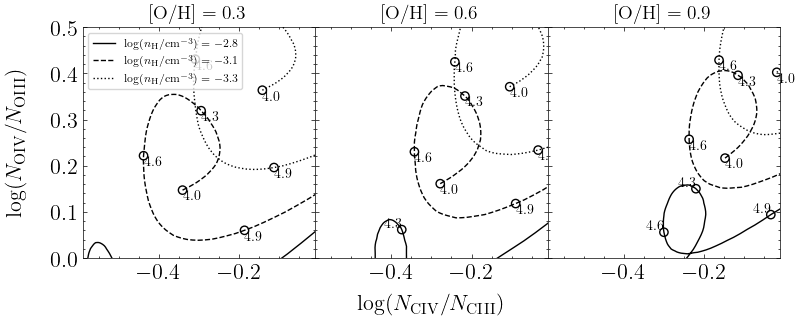

In [131]:
fig, axes = plt.subplots(1,3,figsize=(3*3,3), sharex=True, sharey=True)

# Plot measurements

scat_logN_ratio(axes[0], 'CIV/CIII', 'OIV/OIII', logN_ratio_dict)
axes[0].set_title(r'$\mathrm{[O/H]}=0.3$', fontsize=14)

scat_logN_ratio(axes[1], 'CIV/CIII', 'OIV/OIII', logN_ratio_dict)
axes[1].set_title(r'$\mathrm{[O/H]}=0.6$', fontsize=14)

scat_logN_ratio(axes[2], 'CIV/CIII', 'OIV/OIII', logN_ratio_dict)
axes[2].set_title(r'$\mathrm{[O/H]}=0.9$', fontsize=14)

ax_label = fig.add_subplot(111, frameon=False)
ax_label.set_xticks([])
ax_label.set_yticks([])

ax_label.set_xlabel(r'$\log(N_\mathrm{CIV}/N_\mathrm{CIII})$', labelpad=25)
ax_label.set_ylabel(r'$\log(N_\mathrm{OIV}/N_\mathrm{OIII})$', labelpad=40)

plt.subplots_adjust(wspace=0, hspace=0.0)

# Plot tracks
# metals = -1.0

plot_logN_ratio_track(axes[0], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.3, -2.8, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[0], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.3, -3.1, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[0], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.3, -3.3, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      ':', 'left', 'top')

axes[0].legend(fontsize=8)

# metals = -0.3

plot_logN_ratio_track(axes[1], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.6, -2.8, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[1], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.6, -3.1, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[1], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.6, -3.3, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      ':', 'left', 'top')

# metals = 0.0

plot_logN_ratio_track(axes[2], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.9, -2.8, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '-', 'right', 'bottom')

plot_logN_ratio_track(axes[2], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.9, -3.1, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      '--', 'left', 'top')

plot_logN_ratio_track(axes[2], 'CIII', 'CIV', 'OIII', 'OIV', logX_dict_TDP_interp,
                      0.9, -3.3, 
                      4.0, 5.0, .01,
                      4.0, 5.0, .3,
                      -0.59,-0.01, 0.0,0.5,
                      ':', 'left', 'top')

## HI

Text(0, 0.5, '$\\log(N_\\mathrm{HI}/\\mathrm{cm}^{-2})$')

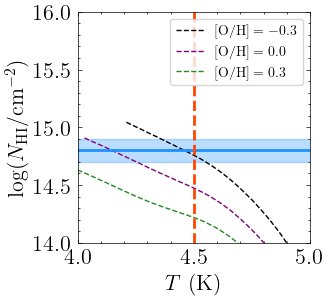

In [14]:
fig, ax = plt.subplots(1, figsize=(3,3))

logT_filt, logN_HI_filt = get_logN_HI('OIV', 14.47, -0.3, -3.0, logT_arr, logX_dict_TDP_interp)
ax.plot(logT_filt, logN_HI_filt,color='black', linestyle='--', label=r'$\mathrm{[O/H]}=-0.3$')

logT_filt, logN_HI_filt = get_logN_HI('OIV', 14.47, 0.0, -3.0, logT_arr, logX_dict_TDP_interp)
ax.plot(logT_filt, logN_HI_filt,color='purple', linestyle='--', label=r'$\mathrm{[O/H]}=0.0$')

logT_filt, logN_HI_filt = get_logN_HI('OIV', 14.47, 0.3, -3.0, logT_arr, logX_dict_TDP_interp)
ax.plot(logT_filt, logN_HI_filt,color='forestgreen', linestyle='--', label=r'$\mathrm{[O/H]}=0.3$')

ax.axhline(14.8, color='dodgerblue', lw=2)
ax.axhspan(14.7,14.9, color='dodgerblue',alpha=.3)
ax.axvline(4.5, color='orangered', lw=2, linestyle='--')

ax.set_xlim(4.0, 5.0)
ax.set_ylim(14, 16)

ax.legend(fontsize=10, loc='upper right')
ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$\log(N_\mathrm{HI}/\mathrm{cm}^{-2})$')

## Fit column densities - two phase

In [31]:
def log_prior_3(log_metals_p1, log_hdens_p1, logT_p1, C_O_p1, N_O_p1,
                log_metals_p2, log_hdens_p2, logT_p2, C_O_p2, N_O_p2, logN_HI_p2, logX_dict_TDP_interp):
        
    logN_HI_obs = 14.5
    
    if log_metals_arr[0]<log_metals_p1<log_metals_arr[-1] and log_metals_arr[0]<log_metals_p2<log_metals_arr[-1]:
        if -3<log_metals_p1+C_O_p1<1 and -3<log_metals_p2+C_O_p2<1 and -3<log_metals_p1+N_O_p1<1 and -3<log_metals_p2+N_O_p2<1:
            if log_hdens_arr[0]<log_hdens_p1<-2.3 and log_hdens_arr[0]<log_hdens_p2<log_hdens_arr[-1]:
                if 4.0<logT_p1<4.9 and 4.0<logT_p2<4.8: #
                    if 12.0<logN_HI_p2<logN_HI_obs:
                        if log_hdens_p1>log_hdens_p2 and logT_p1<logT_p2: # CIV denser and colder
                            logl_p1 = get_logl_TDP(log_metals_p1, log_hdens_p1, logT_p1, logN_HI_obs, logX_dict_TDP_interp)
                            logl_p2 = get_logl_TDP(log_metals_p2, log_hdens_p2, logT_p2, logN_HI_p2, logX_dict_TDP_interp)
                            if logl_p1 < logl_p2 < 2:
                                return np.log(10**log_hdens_p1) + np.log(10**logT_p1) + np.log(10**log_hdens_p2) + np.log(10**logT_p2) + np.log(10**logN_HI_p2)
                                #else:
                                #    return -np.inf
                            else:
                                return -np.inf
                        else:
                            return -np.inf
                    else:
                        return -np.inf
                else:
                    return -np.inf
            else:
                return -np.inf
        else:
            return -np.inf
    else:
        return -np.inf

In [32]:
def log_likelihood_3(log_metals_p1, log_hdens_p1, logT_p1, C_O_p1, N_O_p1,
                     log_metals_p2, log_hdens_p2, logT_p2, C_O_p2, N_O_p2, logN_HI_p2,
                     logN_dict, logX_dict_TDP_interp):
    
    logN_HI_obs = 14.5 # Measured N(HI) to generate column densities
    
    ll = 0
    
    for ion in list(logN_dict.keys()):
        
        if ion == 'HI':
            # For HI there is nothing to bring from the grid
            y_bar_p1 = logN_HI_obs
            y_bar_p2 = logN_HI_p2
            
        else:
            # Model side: prediction adjusted for elemental abundance
            elem = ion_species_dict[ion].split('+')[0]

            y_bar_p1 = predict_col_dens_TDP(ion, log_metals_p1, log_hdens_p1, logT_p1, logN_HI_obs, logX_dict_TDP_interp)
            y_bar_p2 = predict_col_dens_TDP(ion, log_metals_p2, log_hdens_p2, logT_p2, logN_HI_p2, logX_dict_TDP_interp)

            if elem == 'C': 
                y_bar_p1 += C_O_p1
                y_bar_p2 += C_O_p2

            if elem == 'N':
                y_bar_p1 += N_O_p1
                y_bar_p2 += N_O_p2
          
        y_bar = np.log10(10**y_bar_p1 + 10**y_bar_p2)
            
        # Data side: handle upper limits, lower limits, and measurements separately
        logN_str = logN_dict[ion]
        
        ll += compute_ll(logN_str, y_bar)

    return ll

In [33]:
def log_probability_3(params, logN_dict, logX_dict_TDP_interp):
    
    log_metals_p1,log_hdens_p1,logT_p1,C_O_p1,N_O_p1,log_metals_p2,log_hdens_p2,logT_p2,C_O_p2,N_O_p2,logN_HI_p2 = params
    
    lp = log_prior_3(log_metals_p1,log_hdens_p1,logT_p1,C_O_p1,N_O_p1,log_metals_p2,log_hdens_p2,logT_p2,C_O_p2,N_O_p2,logN_HI_p2,logX_dict_TDP_interp)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp+log_likelihood_3(log_metals_p1,log_hdens_p1,logT_p1,C_O_p1,N_O_p1,log_metals_p2,log_hdens_p2,logT_p2,C_O_p2,N_O_p2,logN_HI_p2,logN_dict,logX_dict_TDP_interp)

In [34]:
logN_dict = {'HI':'14.5, -0.1, +0.1',
            'HeI':'<13.1',
            'CII':'<13.0',
            'CIII':'13.1, -0.4, +0.3',
            'CIV':'13.52, -0.03, +0.03',
            'NIV':'13.0, -0.1, +0.1',
            'NV':'<13.3',
            'OIII':'13.6, -0.1, +0.1',
            'OIV':'13.9, -0.2, +0.1',
            'OV':'<13.6',
            'OVI':'<13.8',
            'NeV':'<13.7',
            'MgII':'<11.3',
            #'MgX':'<13.6',
            #'AlII':'<11.1',
            #'AlIII':'<11.5',
            'SiII':'<12.1',
            'SIV':'<13.9',
            'SVI':'<13.3',}
            #'FeII':'<11.6',}

In [35]:
log_metals_test_p1 = -1.1
log_hdens_test_p1 = -3.0
logT_test_p1 = 4.4
C_O_test_p1 = -1.3
N_O_test_p1 = -1.3
logN_HI_test_p1 = 14.5

logN_test_p1 = predict_col_dens_model_TDP(logN_dict,log_metals_test_p1,log_hdens_test_p1,logT_test_p1,logN_HI_test_p1,logX_dict_TDP_interp,C_O_test_p1,N_O_test_p1)

log_metals_test_p2 = 0.0
log_hdens_test_p2 = -3.7
logT_test_p2 = 4.8
C_O_test_p2 = 0.6
N_O_test_p2 = 0.0
logN_HI_test_p2 = 13.0

logN_test_p2 = predict_col_dens_model_TDP(logN_dict,log_metals_test_p2,log_hdens_test_p2,logT_test_p2,logN_HI_test_p2,logX_dict_TDP_interp,C_O_test_p2,N_O_test_p2)

logN_test = np.log10(10**logN_test_p1 + 10**logN_test_p2)

In [36]:
get_logl_TDP(log_metals_test_p1, log_hdens_test_p1, logT_test_p1, logN_HI_test_p1, logX_dict_TDP_interp)

-0.5319888913766988

In [37]:
get_logl_TDP(log_metals_test_p2, log_hdens_test_p2, logT_test_p2, logN_HI_test_p2, logX_dict_TDP_interp)

-0.1900094841365103

(12.0, 15.0)

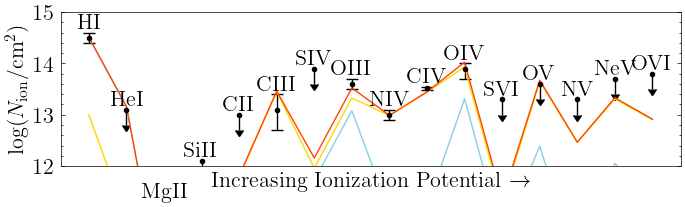

In [38]:
fig, ax = plt.subplots(1, figsize=(8,2))

plot_column_densities_obs(logN_dict, fig, ax)
ax.plot(np.arange(len(logN_dict)), logN_test_p1, color='skyblue')
ax.plot(np.arange(len(logN_dict)), logN_test_p2, color='gold')
ax.plot(np.arange(len(logN_dict)), logN_test, color='orangered')

ax.set_ylim(12.,15)

In [39]:
pos = np.array([log_metals_test_p1,log_hdens_test_p1,logT_test_p1,C_O_test_p1,N_O_test_p1, 
                log_metals_test_p2,log_hdens_test_p2,logT_test_p2,C_O_test_p2,N_O_test_p2,logN_HI_test_p2]) + 1e-4 * np.random.randn(200, 11)
nwalkers, ndim = pos.shape

In [40]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability_3, args=(logN_dict,logX_dict_TDP_interp)
)

In [41]:
#sampler.run_mcmc(pos, 500, progress=True);

In [42]:
#flat_samples_3 = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_metals_p1','log_hdens_p1','logT_p1','C_O_p1','N_O_p1',
#                                         'log_metals_p2','log_hdens_p2','logT_p2','C_O_p2','N_O_p2','logN_HI_p2'])
#flat_samples_3.to_csv(savedir+'TDP_c4.csv', index=False)

flat_samples_3 = pd.read_csv(savedir+'TDP_c4.csv')

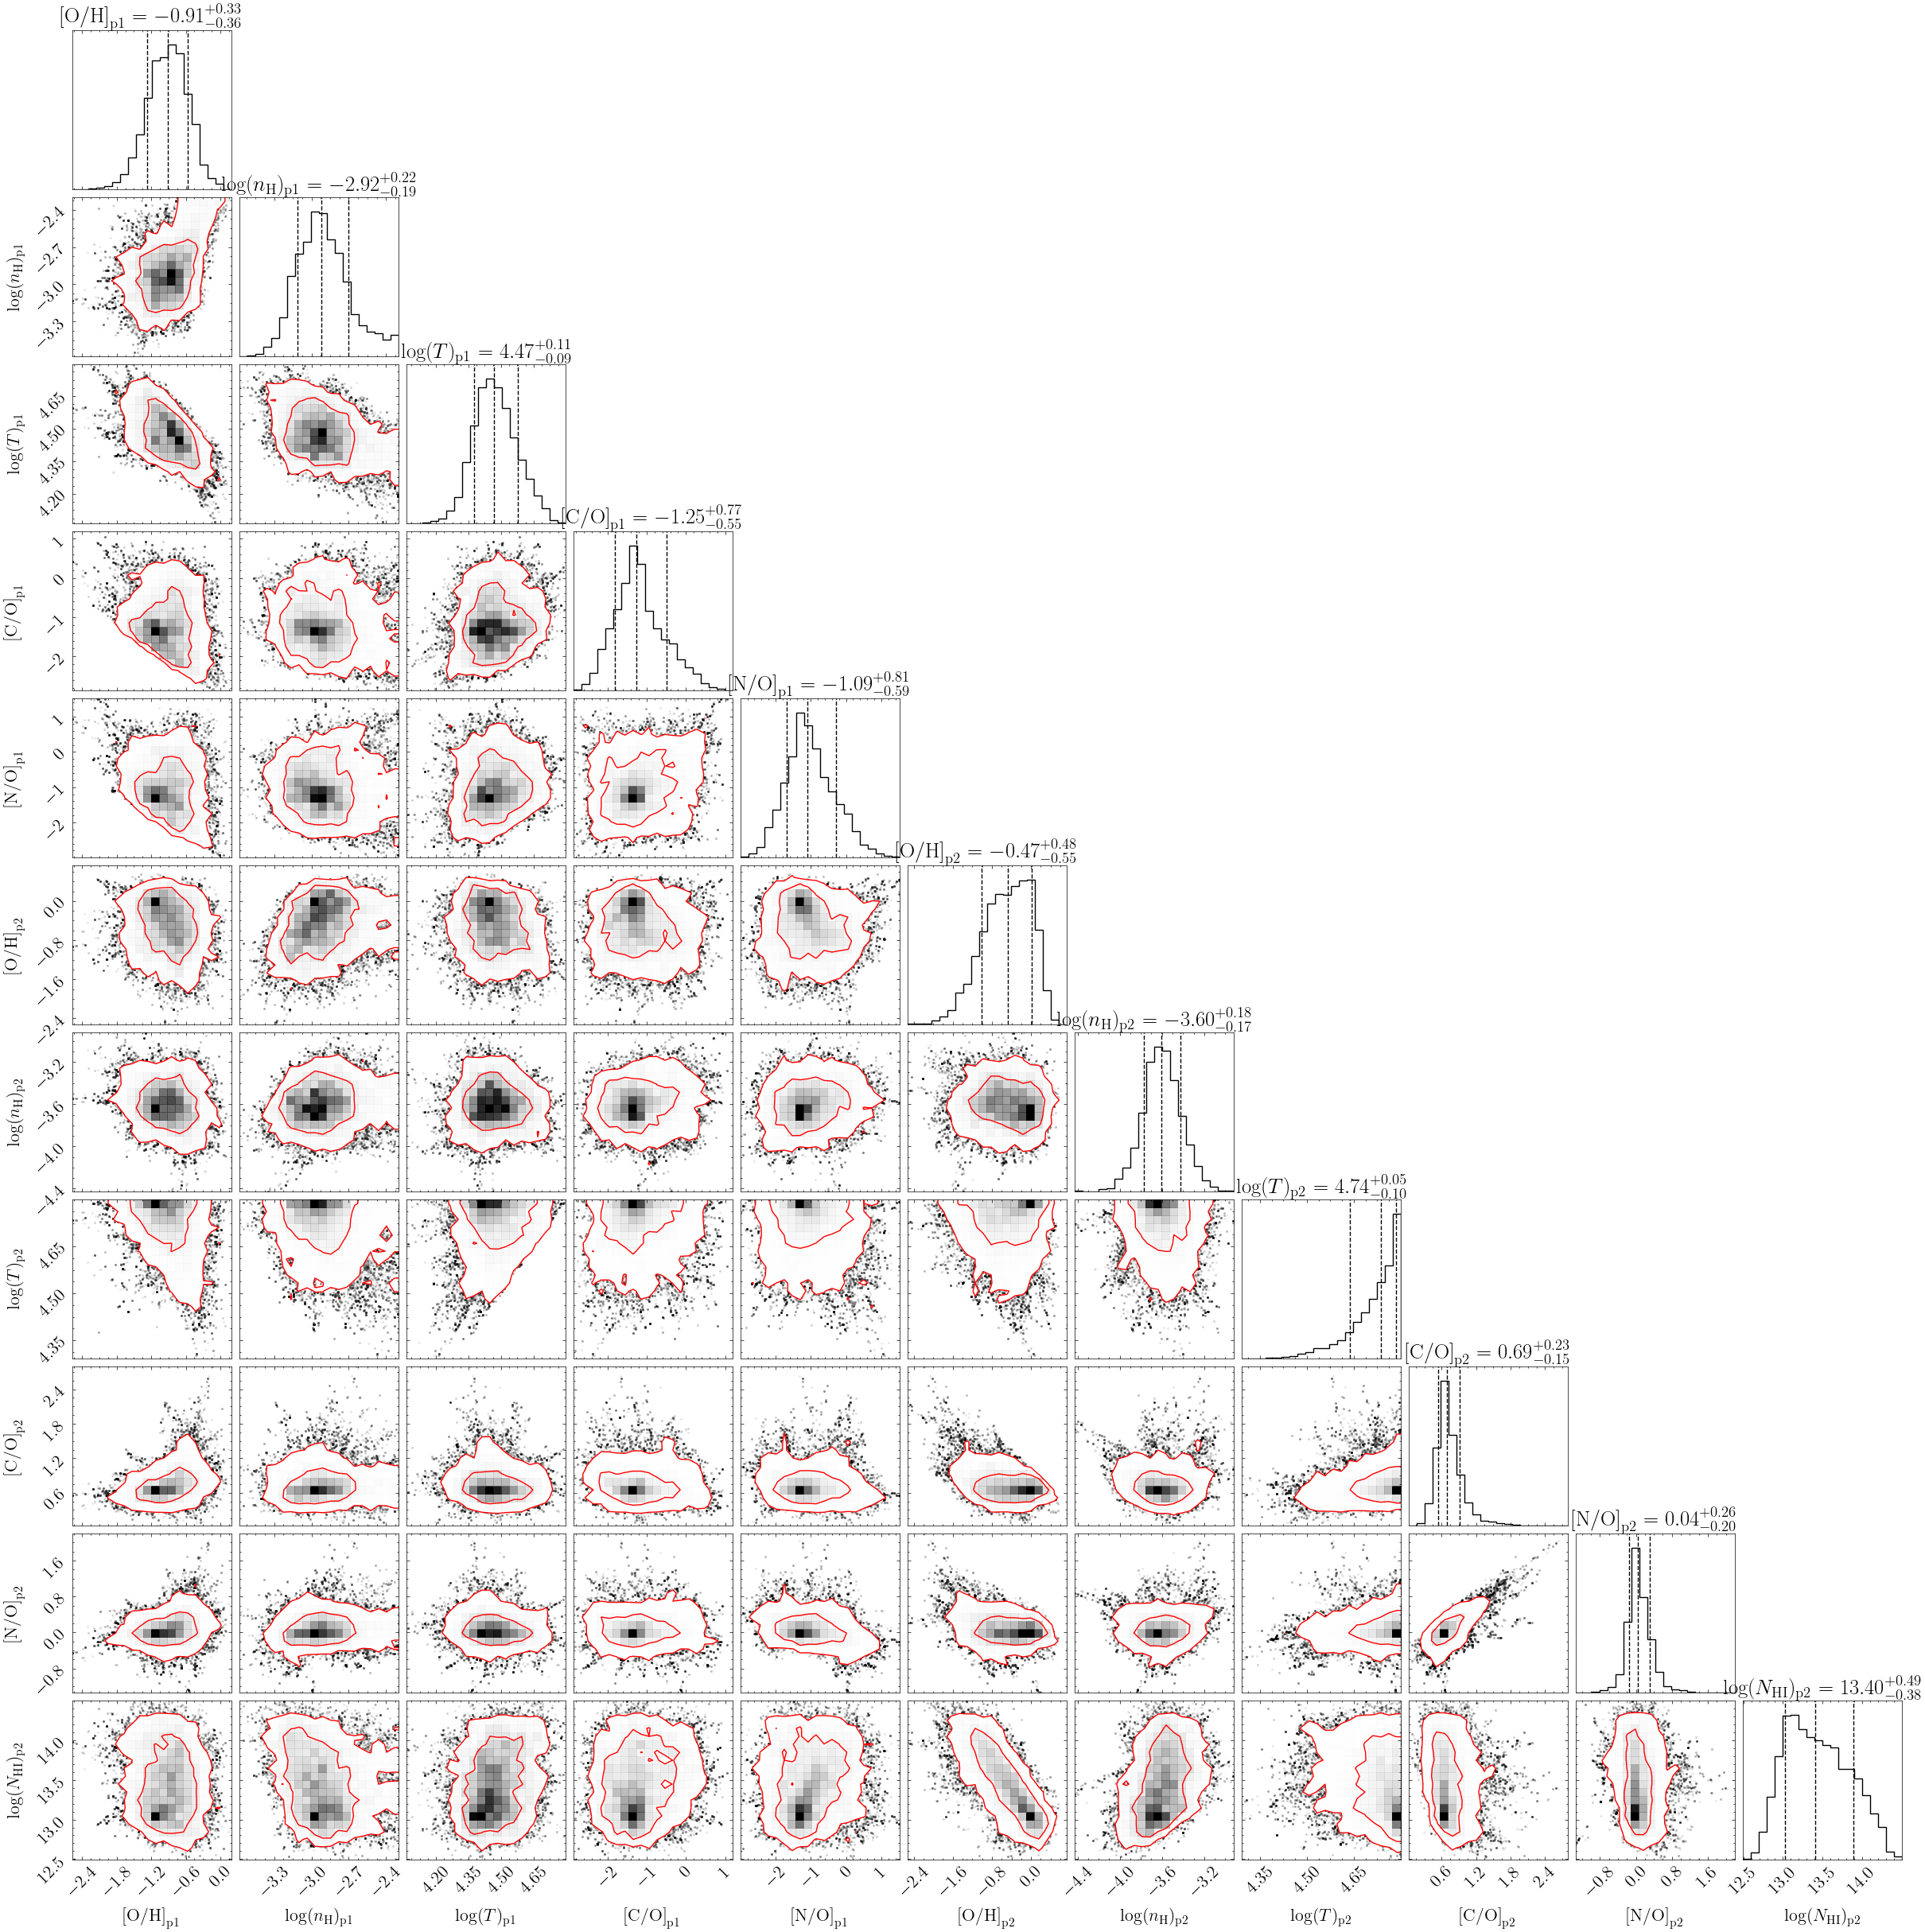

In [43]:
fig = corner.corner(
    flat_samples_3, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\mathrm{[O/H]}_\mathrm{p1}$',r'$\log(n_\mathrm{H})_\mathrm{p1}$',r'$\log(T)_\mathrm{p1}$',r'$\mathrm{[C/O]}_\mathrm{p1}$',r'$\mathrm{[N/O]}_\mathrm{p1}$',
            r'$\mathrm{[O/H]}_\mathrm{p2}$',r'$\log(n_\mathrm{H})_\mathrm{p2}$',r'$\log(T)_\mathrm{p2}$',r'$\mathrm{[C/O]}_\mathrm{p2}$',r'$\mathrm{[N/O]}_\mathrm{p2}$',
            r'$\log(N_\mathrm{HI})_\mathrm{p2}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [44]:
np.percentile(flat_samples_3['logT_p1'], 100*cdf_3sig)

4.756461052545722

(array([  252.,  1362.,  4615.,  7661.,  9707., 11703., 11956., 12378.,
        11404.,  8962.]),
 array([-1.06780355, -0.86106007, -0.65431659, -0.44757311, -0.24082963,
        -0.03408615,  0.17265733,  0.37940081,  0.58614429,  0.79288777,
         0.99963125]),
 <BarContainer object of 10 artists>)

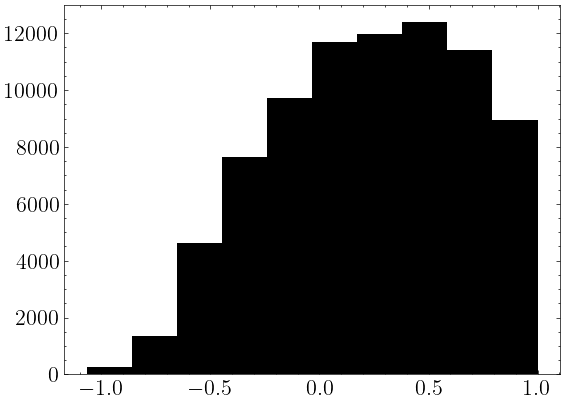

In [45]:
plt.hist(flat_samples_3['log_metals_p2']+flat_samples_3['C_O_p2'])

(array([   77.,   444.,  1755.,  6202., 11550., 16646., 17465., 16493.,
         8979.,   389.]),
 array([-2.31169255, -2.0040016 , -1.69631064, -1.38861969, -1.08092873,
        -0.77323777, -0.46554682, -0.15785586,  0.14983509,  0.45752605,
         0.765217  ]),
 <BarContainer object of 10 artists>)

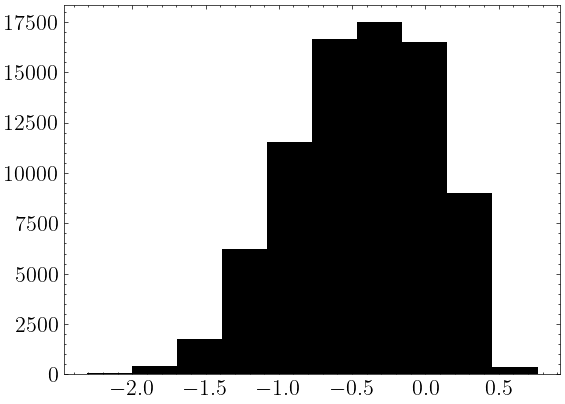

In [46]:
plt.hist(flat_samples_3['log_metals_p2']+flat_samples_3['N_O_p2'])

In [47]:
np.percentile(flat_samples_3['C_O_p1'], 100*cdf_3sig), np.percentile(flat_samples_3['N_O_p1'], 100*cdf_3sig)

(0.8353690072017842, 1.1713117609215014)

Make a plot

In [48]:
logN_dict = {#'HI':'14.5, -0.1, +0.1',
            'HeI':'<13.1',
            'CII':'<13.0',
            'CIII':'13.1, -0.4, +0.3',
            'CIV':'13.52, -0.03, +0.03',
            'NIV':'13.0, -0.1, +0.1',
            'NV':'<13.3',
            'OIII':'13.6, -0.1, +0.1',
            'OIV':'13.9, -0.2, +0.1',
            'OV':'13.6, -0.2, +0.1',
            'OVI':'<13.8',
            'NeV':'<13.7',
            'MgII':'<11.3',
            #'MgX':'<13.6',
            #'AlII':'<11.1',
            #'AlIII':'<11.5',
            'SiII':'<12.1',
            'SIV':'<13.9',
            'SVI':'<13.3',}
            #'FeII':'<11.6',}

In [49]:
b_dict = {'HI':'22, -5, +5',
          'CIII':'8.2, -0.6, +0.6',
          'CIV':'8.2, -0.6, +0.6',
          'NIV':'8.2, -0.6, +0.6',
          'OIII':'8.2, -0.6, +0.6',
          'OIV':'8.2, -0.6, +0.6',
          'OV':'17, -3, +4'}

In [60]:
p3_grid = np.array(flat_samples_3)

yb_med_p1 = np.zeros(len(logN_dict))
yb_lo_p1 = np.zeros(len(logN_dict))
yb_hi_p1 = np.zeros(len(logN_dict))

yb_med_p2 = np.zeros(len(logN_dict))
yb_lo_p2 = np.zeros(len(logN_dict))
yb_hi_p2 = np.zeros(len(logN_dict))

yb_med = np.zeros(len(logN_dict))
yb_lo = np.zeros(len(logN_dict))
yb_hi = np.zeros(len(logN_dict))

ctr = 0

for i in range(len(ion_species_dict)):
    
    ion = list(ion_species_dict.keys())[i]
    
    if ion in list(logN_dict.keys()):
        elem = ion_species_dict[ion].split('+')[0]

        y_samples_p1 = predict_col_dens_TDP(ion, p3_grid[:,0], p3_grid[:,1], p3_grid[:,2], 14.5, logX_dict_TDP_interp)
        y_samples_p2 = predict_col_dens_TDP(ion, p3_grid[:,5], p3_grid[:,6], p3_grid[:,7], p3_grid[:,10], logX_dict_TDP_interp)
        
        if elem == 'C':
            y_samples_p1 += p3_grid[:,3]
            y_samples_p2 += p3_grid[:,8]
            
        if elem == 'N':
            y_samples_p1 += p3_grid[:,4]
            y_samples_p2 += p3_grid[:,9]
            
        y_samples = np.log10(10**y_samples_p1 + 10**y_samples_p2) 
        
        yb_med_p1[ctr] = np.median(y_samples_p1)
        yb_lo_p1[ctr] = np.percentile(y_samples_p1, 16)
        yb_hi_p1[ctr] = np.percentile(y_samples_p1, 84)
        
        yb_med_p2[ctr] = np.median(y_samples_p2)
        yb_lo_p2[ctr] = np.percentile(y_samples_p2, 16)
        yb_hi_p2[ctr] = np.percentile(y_samples_p2, 84)
        
        yb_med[ctr] = np.median(y_samples)
        yb_lo[ctr] = np.percentile(y_samples, 16)
        yb_hi[ctr] = np.percentile(y_samples, 84)
        
        ctr += 1

In [61]:
import matplotlib.lines as mlines

In [62]:
z_sys = 1.04430667

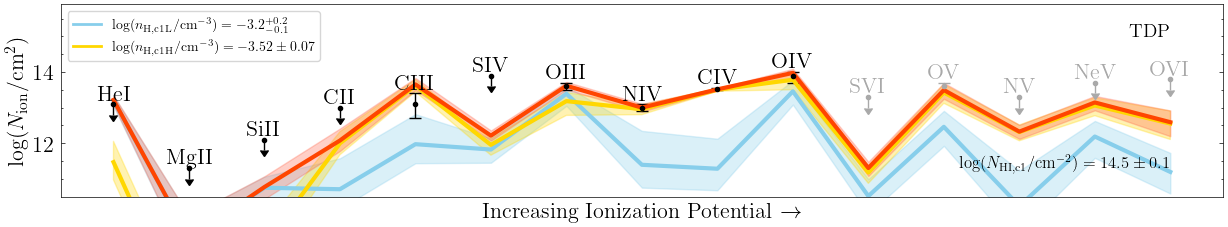

In [63]:
fig, ax = plt.subplots(1, figsize=(15,2.5))

plot_column_densities_obs(logN_dict, fig, ax,
                          gray_out = ['NV', 'OV', 'OVI', 'NeV', 'SVI'])

ax.plot(np.arange(len(logN_dict)), yb_med_p1, lw=3, color='skyblue')
ax.fill_between(np.arange(len(logN_dict)), yb_lo_p1, yb_hi_p1, color='skyblue', alpha=.3)

ax.plot(np.arange(len(logN_dict)), yb_med_p2, lw=3, color='gold')
ax.fill_between(np.arange(len(logN_dict)), yb_lo_p2, yb_hi_p2, color='gold', alpha=.3)

ax.plot(np.arange(len(logN_dict)), yb_med, lw=3, color='orangered')
ax.fill_between(np.arange(len(logN_dict)), yb_lo, yb_hi, color='tomato', alpha=.3)

ax.set_ylim(10.5,15.9)

handles = []

handles.append(mlines.Line2D([], [], lw=2,
                             color='skyblue', 
                             marker='None',
              linestyle='-', markersize=8, label=r'$\log(n_\mathrm{H, c1L}/\mathrm{cm}^{-3}) = -3.2_{-0.1}^{+0.2}$'))

handles.append(mlines.Line2D([], [], lw=2,
                             color='gold', 
                             marker='None',
              linestyle='-', markersize=8, label=r'$\log(n_\mathrm{H, c1H}/\mathrm{cm}^{-3}) = -3.52 \pm 0.07$'))
    
ax.text(len(logN_dict)-1, 15.0, r'TDP',fontsize=14, horizontalalignment='right')
ax.text(len(logN_dict)-1, 11.3, r'$\log(N_\mathrm{HI, c1}/\mathrm{cm}^{-2}) = 14.5 \pm 0.1$', fontsize=12,
            horizontalalignment='right')

ax.legend(handles=handles, loc='upper left', fontsize=10)

plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z={}/z={}_c4_TDP.pdf'.format(z_sys, str(z_sys).replace('.', '_')), dpi=150)
plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z={}/z={}_c4_TDP.png'.format(z_sys, str(z_sys).replace('.', '_')), dpi=150)

In [64]:
yb_med_p2[-10], yb_med_p2[-10]-yb_lo_p2[-10], yb_hi_p2[-10]-yb_med_p2[-10]

(11.955864217790692, 0.2901769280554358, 0.17564985833768532)

In [70]:
logl_p1 = get_logl_TDP(p3_grid[:,0], p3_grid[:,1], p3_grid[:,2], 14.5, logX_dict_TDP_interp)
logl_p2 = get_logl_TDP(p3_grid[:,5], p3_grid[:,6], p3_grid[:,7], p3_grid[:,10], logX_dict_TDP_interp)

(array([ 1298.,  3255.,  4605., 10934., 19722., 21044., 13498.,  4397.,
         1139.,   108.]),
 array([-2.09625058, -1.79354147, -1.49083236, -1.18812325, -0.88541414,
        -0.58270503, -0.27999592,  0.02271319,  0.3254223 ,  0.62813141,
         0.93084052]),
 <BarContainer object of 10 artists>)

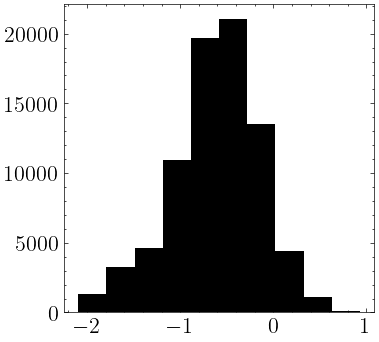

In [71]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logl_p1)

In [72]:
get_quantiles(logl_p1)

-0.58 -0.48 0.41


(array([  189.,  2328., 11253., 23016., 21249., 13126.,  6574.,  1841.,
          332.,    92.]),
 array([-1.35129418, -1.04445783, -0.73762147, -0.43078511, -0.12394875,
         0.18288761,  0.48972397,  0.79656033,  1.10339668,  1.41023304,
         1.7170694 ]),
 <BarContainer object of 10 artists>)

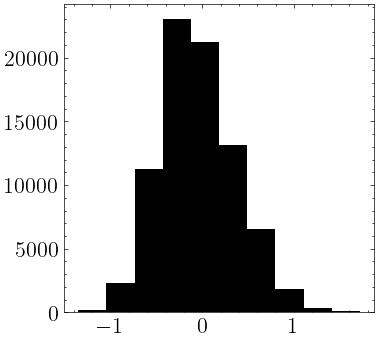

In [73]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logl_p2)

In [74]:
get_quantiles(logl_p2)

-0.08 -0.37 0.47
